In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from pmdarima.arima import ndiffs

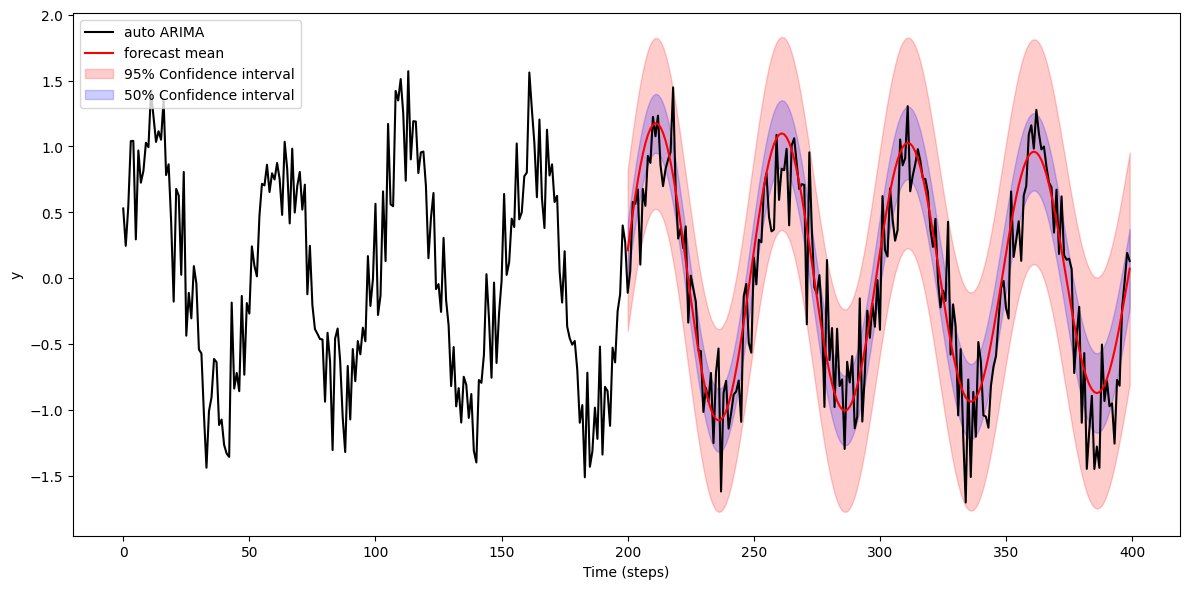

In [13]:
np.random.seed(0)

n = 400
t = np.arange(n)

signal = np.sin(2*np.pi*t/50)+0.3*np.random.randn(n)

data = pd.Series(signal)

split = 200
kpss_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)

model = auto_arima(
    data.iloc[:split],
    seasonal=True,
    suppress_warnings=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
from external.api_repo.generators import *
from external.api_repo.utils import *

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 30
time_step = 4e-3

barrier_height=0.9e-8
left_well=3
right_well=-3
x0_mean=0
tilt=0#1e-12#2e-50
num_of_simulations=8


x,dwt=double_wells_generator(total_time=total_time, zeta=zeta,T=T,time_step=time_step,boltzmann=boltzman,right_well=right_well,left_well=left_well,
                          barrier_height=barrier_height,x0_mean=x0_mean,device=device  ,num_of_simulations=num_of_simulations,tilt=tilt)

In [25]:
x_single = x[0]
data = pd.Series(x_single.detach().cpu().numpy())

In [26]:
np.random.seed(0)

split = 3000
train_data=data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-584.218, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-602.913, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-619.030, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-627.989, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-604.898, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-624.074, Time=0.54 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-630.469, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-628.198, Time=0.28 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-622.838, Time=0.77 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-627.245, Time=1.13 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-631.858, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-629.654, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-629.622, Time=0.11 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-598.898, Time=0.20 sec
 ARIMA(1,1,1)(0,0,0)[0]          

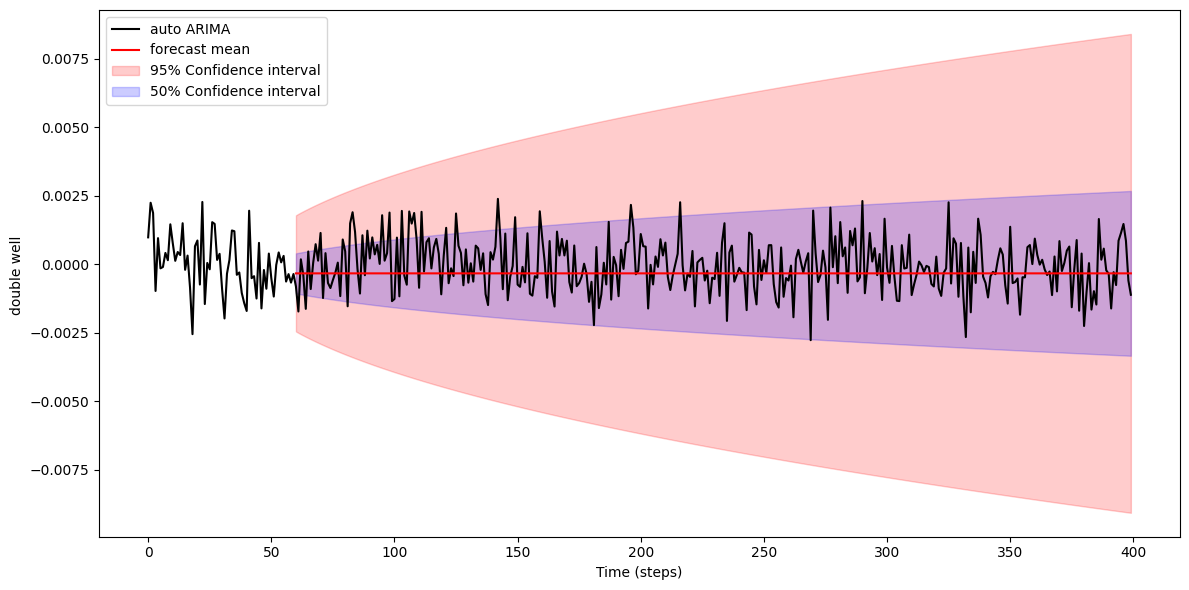

In [36]:
model = auto_arima(train_data,d=n_diffs,suppress_warnings=True, error_action="ignore",max_order=None, trace=True)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=325.666, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=312.202, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=306.740, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=323.684, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=308.320, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=308.220, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=308.607, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=304.821, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=306.404, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=306.305, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=310.243, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=306.862, Time=0.15 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.522 seconds


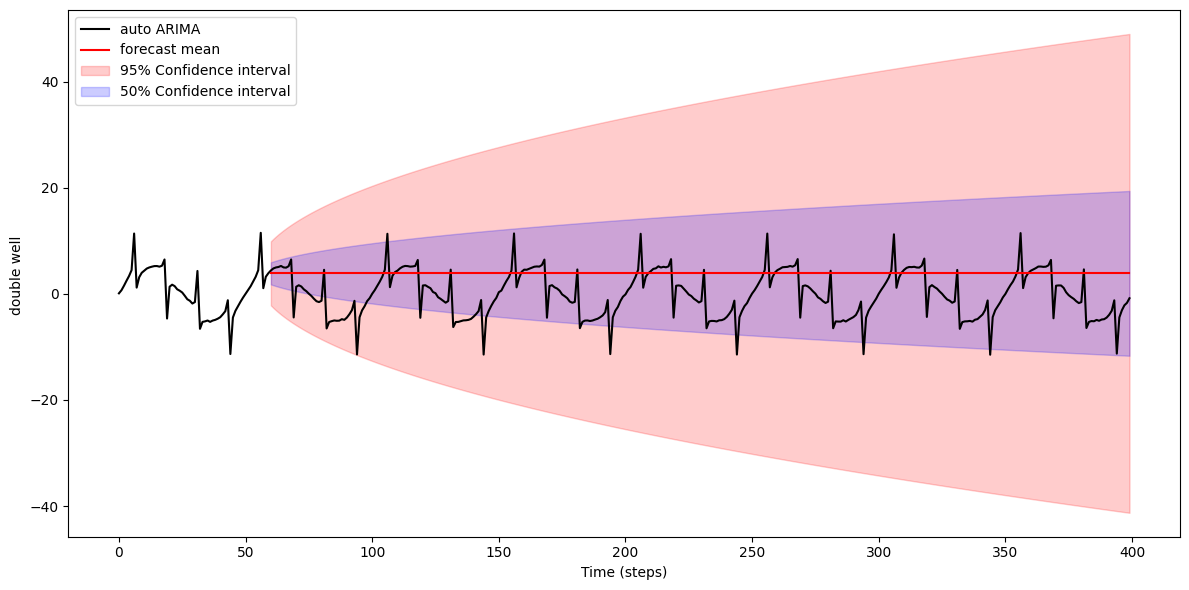

In [ ]:
signal = 5*np.sin(2*np.pi*t/50)+0.5*np.tan(2*np.pi*t/25)+0.1*np.random.randn(n)
data = pd.Series(signal)
split=150
train_data = data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)

model = auto_arima(train_data,seasonal=True,d=n_diffs,suppress_warnings=True, error_action="ignore",max_order=None, trace=True)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black", label="auto ARIMA")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()
